# Setudent Performance Regression Analysis

## 1. Introduction

##### This project investigates factors associated with student exam performance using exploratory data analysis and multiple linear regression, including coefficient interpretation, statistical inference, model diagnostics, and discussion of limitations.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [68]:
sns.set_theme(style="darkgrid", palette="husl")

## 2. Data Overview and Missing Value Handling

In [69]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [71]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

In [72]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Categorical variables:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [73]:
df_clean = df.copy()
missing_cat_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in missing_cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isnull().sum().sum()

np.int64(0)

## 3. Exploratory Data Analysis

#### 3.1 Correlation Heatmap

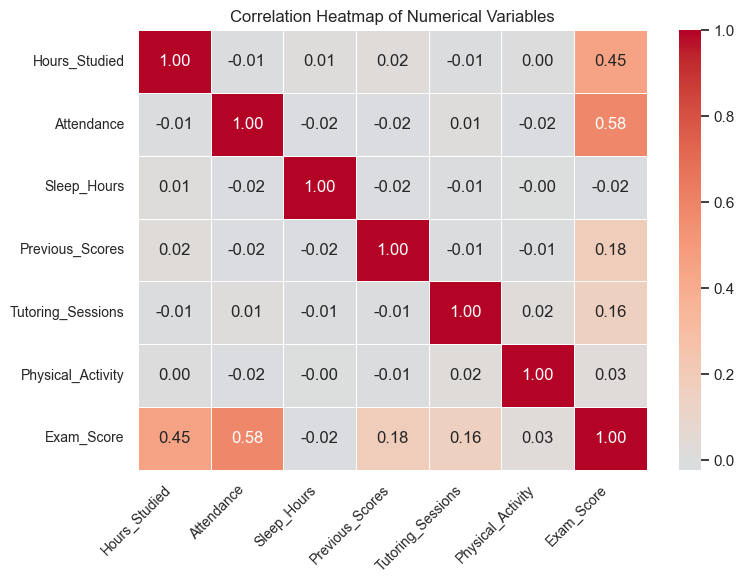

In [74]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#### 3.2 Numerical Relationships

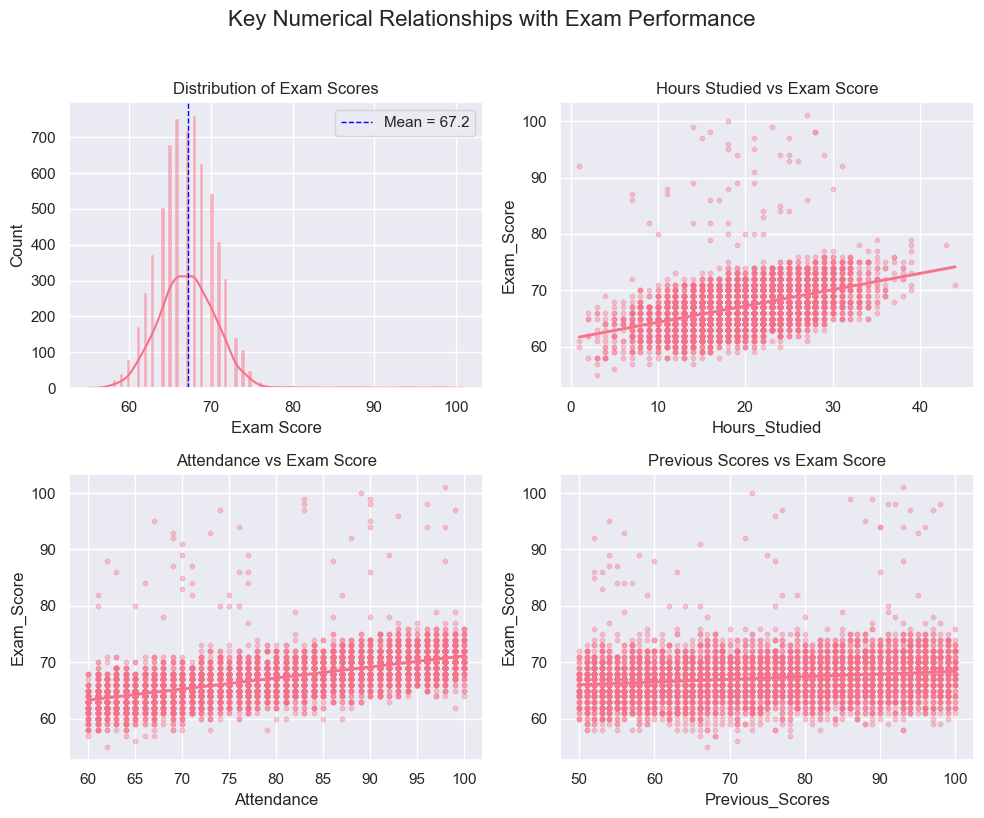

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
mean_score = df_clean["Exam_Score"].mean()

# Distribution of Exam Scores
sns.histplot(
    data=df_clean,
    x="Exam_Score",          
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].axvline(
    mean_score,
    linestyle="--",
    linewidth=1,
    color="blue",
    label=f"Mean = {mean_score:.1f}"
)

axes[0, 0].set_title("Distribution of Exam Scores")
axes[0, 0].set_xlabel("Exam Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# Hours Studied vs Exam Score
sns.regplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha": 0.35, "s": 10},
    line_kws={"linewidth": 2},
    ax=axes[0, 1]
)
axes[0, 1].set_title("Hours Studied vs Exam Score")

# Attendance vs Exam Score
sns.regplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    scatter_kws={"alpha": 0.35, "s": 10},
    line_kws={"linewidth": 2},
    ax=axes[1, 0]
)
axes[1, 0].set_title("Attendance vs Exam Score")

# Previous Scores vs Exam Score
sns.regplot(
    data=df_clean,
    x="Previous_Scores",
    y="Exam_Score",
    scatter_kws={"alpha": 0.35, "s": 10},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title("Previous Scores vs Exam Score")

plt.suptitle(
    "Key Numerical Relationships with Exam Performance",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

#### 3.3 Categorical Relationships

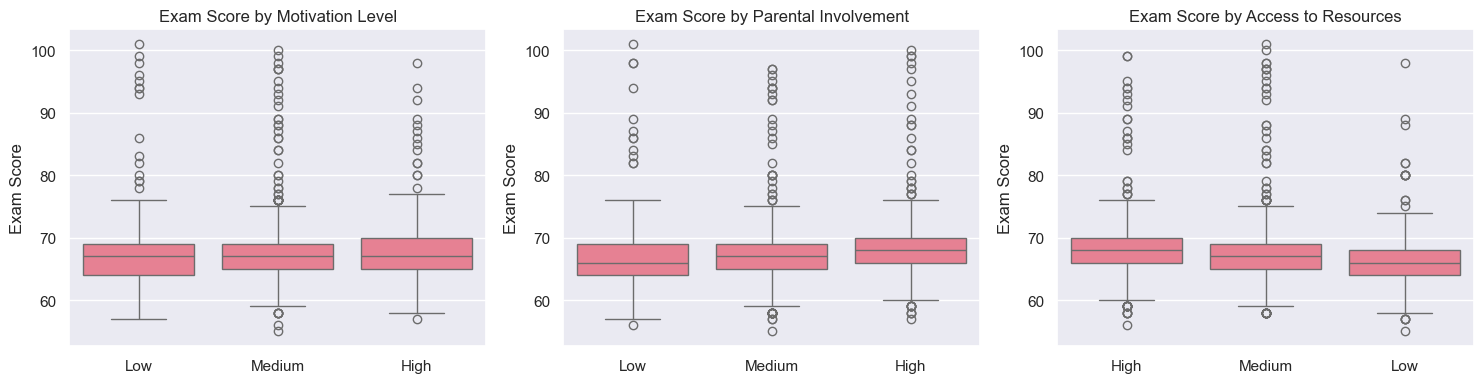

In [76]:
important_cat_cols = [
    "Motivation_Level",
    "Parental_Involvement",
    "Access_to_Resources"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, important_cat_cols):
    sns.boxplot(
        data=df_clean,
        x=col,
        y="Exam_Score",
        ax=ax
    )
    ax.set_title(f"Exam Score by {col.replace('_', ' ')}")
    ax.set_xlabel("")
    ax.set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

## 4. Multiple Linear Regression

#### Regression Data Preparation

In [77]:
df_model = df_clean.copy()
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

df_model = df_model.astype(float)

X = df_model.drop(columns="Exam_Score")
y = df_model["Exam_Score"]
X = sm.add_constant(X)

#### Multiple Linear Regression Model

In [78]:
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     649.9
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        12:15:56   Log-Likelihood:                -14058.
No. Observations:                6607   AIC:                         2.817e+04
Df Residuals:                    6579   BIC:                         2.836e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [79]:
print("Model Fit Summary")
print("-" * 30)
print(f"R-squared: {ols_model.rsquared:.3f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.3f}")
print(f"F-statistic: {ols_model.fvalue:.1f}")
print(f"Prob (F-statistic): {ols_model.f_pvalue:.2f}")

Model Fit Summary
------------------------------
R-squared: 0.727
Adjusted R-squared: 0.726
F-statistic: 649.9
Prob (F-statistic): 0.00


## 5. Coefficient Interpretation

In [80]:
coef_table = pd.DataFrame({
    "Coefficient": ols_model.params,
    "P_value": ols_model.pvalues,
    "CI_lower": ols_model.conf_int()[0],
    "CI_upper": ols_model.conf_int()[1]
})

coef_table = coef_table.drop(index="const")
coef_table["Abs_Coefficient"] = coef_table["Coefficient"].abs()

coef_table = coef_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_table.head(15)

,Coefficient,P_value,CI_lower,CI_upper,Abs_Coefficient
Access_to_Resources_Low,-2.055279,2.682959e-166,-2.197678,-1.912880,2.055279
Parental_Involvement_Low,-1.982971,7.127892e-155,-2.125693,-1.840250,1.982971
Family_Income_Low,-1.079055,2.234728e-53,-1.215353,-0.942758,1.079055
Motivation_Level_Low,-1.060733,2.398009e-47,-1.203458,-0.918008,1.060733
Parental_Involvement_Medium,-1.056060,2.867045e-71,-1.170630,-0.941490,1.056060
Teacher_Quality_Low,-1.051581,5.949309e-30,-1.232001,-0.871160,1.051581
Peer_Influence_Positive,1.028934,3.518350e-51,0.896056,1.161811,1.028934
Access_to_Resources_Medium,-1.002079,1.770802e-65,-1.115748,-0.888411,1.002079
Internet_Access_Yes,0.930253,1.632442e-22,0.744138,1.116368,0.930253
Distance_from_Home_Near,0.901646,1.282573e-25,0.733418,1.069874,0.901646


##### The results indicate that both academic behavior and environmental support are associated with exam performance. Attendance and hours studied were among the strongest positive predictors. Higher levels of resources, parental involvement, motivation, and teacher quality were associated with better outcomes, while learning disabilities were associated with lower exam scores.


#### Coefficient plot with confidence intervals

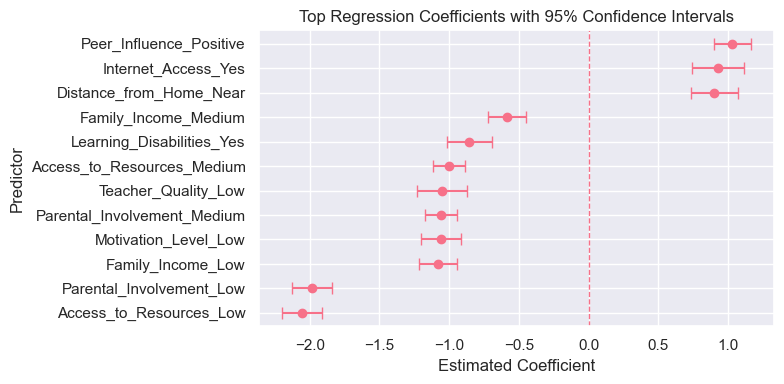

In [81]:
top_coef = coef_table.head(12).copy()
top_coef = top_coef.sort_values("Coefficient")

plt.figure(figsize=(8, 4))
plt.errorbar(
    x=top_coef["Coefficient"],
    y=top_coef.index,
    xerr=[
        top_coef["Coefficient"] - top_coef["CI_lower"],
        top_coef["CI_upper"] - top_coef["Coefficient"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top Regression Coefficients with 95% Confidence Intervals")
plt.xlabel("Estimated Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

## 6. Standardized Coefficients

In [82]:
df_standardized = df_clean.copy()
num_predictors = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

scaler = StandardScaler()
df_standardized[num_predictors + ["Exam_Score"]] = scaler.fit_transform(
    df_standardized[num_predictors + ["Exam_Score"]]
)

df_std_model = pd.get_dummies(
    df_standardized,
    drop_first=True
)

df_std_model = df_std_model.astype(float)
X_std = df_std_model.drop(columns="Exam_Score")
y_std = df_std_model["Exam_Score"]
X_std = sm.add_constant(X_std)
std_model = sm.OLS(y_std, X_std).fit()

In [83]:
std_coef_table = pd.DataFrame({
    "Standardized_Coefficient": std_model.params,
    "P_value": std_model.pvalues
})

std_coef_table = std_coef_table.drop(index="const")
std_coef_table["Abs_Coefficient"] = std_coef_table["Standardized_Coefficient"].abs()
std_coef_table = std_coef_table.sort_values(
    "Abs_Coefficient",
    ascending=False
)

std_coef_table.head(15)

,Standardized_Coefficient,P_value,Abs_Coefficient
Attendance,0.590192,0.000000e+00,0.590192
Access_to_Resources_Low,-0.528327,2.682959e-166,0.528327
Parental_Involvement_Low,-0.509740,7.127892e-155,0.509740
Hours_Studied,0.454226,0.000000e+00,0.454226
Family_Income_Low,-0.277381,2.234728e-53,0.277381
Motivation_Level_Low,-0.272671,2.398009e-47,0.272671
Parental_Involvement_Medium,-0.271470,2.867045e-71,0.271470
Teacher_Quality_Low,-0.270318,5.949309e-30,0.270318
Peer_Influence_Positive,0.264496,3.518350e-51,0.264496
Access_to_Resources_Medium,-0.257593,1.770802e-65,0.257593


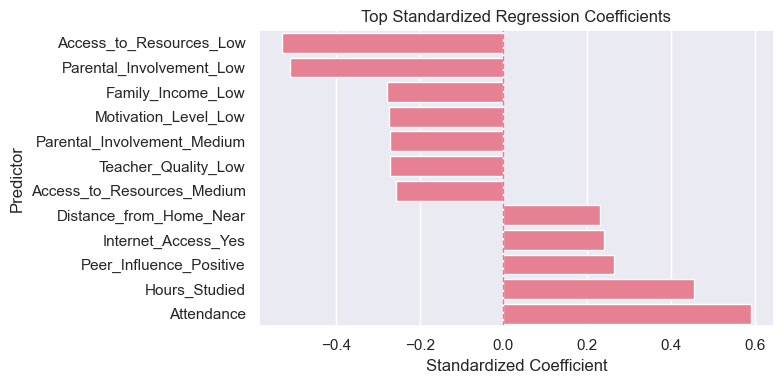

In [84]:
top_std_coef = std_coef_table.head(12).copy()
top_std_coef = top_std_coef.sort_values("Standardized_Coefficient")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_std_coef,
    x="Standardized_Coefficient",
    y=top_std_coef.index
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top Standardized Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

##### The standardized coefficients suggest that attendance and hours studied are among the strongest positive predictors of exam performance, while low access to resources and low parental involvement are among the strongest negative predictors. These results highlight the importance of both academic effort and environmental support.


## 7. Model Diagnostics

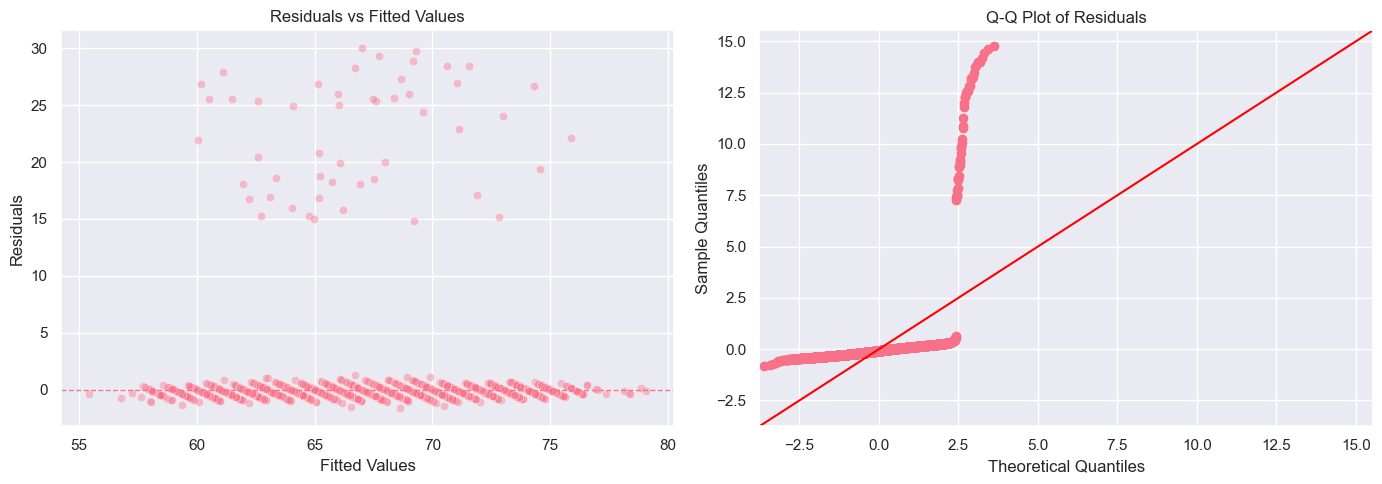

In [85]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.scatterplot(
    x=fitted_values,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")

# Q-Q Plot
sm.qqplot(
    residuals,
    line="45",
    fit=True,
    ax=axes[1]
)

axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

#### Investigate Large Residuals and Influential Points

In [86]:
influence = ols_model.get_influence()
influence_df = pd.DataFrame({
    "Fitted_Value": fitted_values,
    "Residual": residuals,
    "Standardized_Residual": influence.resid_studentized_internal,
    "Cooks_Distance": influence.cooks_distance[0]
})

influence_df = influence_df.sort_values(
    "Standardized_Residual",
    ascending=False
)

top_residual_indices = influence_df.head(10).index
df_clean.loc[top_residual_indices]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Female,97
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
919,21,74,High,Medium,No,6,94,Medium,Yes,1,Low,High,Public,Positive,1,No,High School,Near,Male,97
6393,16,83,Low,Medium,Yes,8,92,Low,Yes,2,High,High,Public,Positive,4,No,Postgraduate,Near,Female,98
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
4297,21,67,Medium,Medium,Yes,6,88,Medium,Yes,1,Low,Medium,Private,Positive,5,No,Postgraduate,Near,Female,95
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89
3457,18,93,Medium,Medium,No,7,76,Low,Yes,2,Medium,Medium,Private,Neutral,4,No,High School,Near,Female,96
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female,98


##### The diagnostic plots suggest that the model captures the main patterns in the data reasonably well. Some unusually high-performing students produce deviations from normality, but influence measures indicate that these observations do not substantially affect the regression results.

## 8. Multicollinearity Check Using VIF

In [87]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data[vif_data["Variable"] != "const"]
vif_data = vif_data.sort_values(
    "VIF",
    ascending=False
)

vif_data.head(15)

,Variable,VIF
25,Distance_from_Home_Moderate,2.822823
26,Distance_from_Home_Near,2.822395
16,Family_Income_Medium,1.858354
15,Family_Income_Low,1.856279
20,Peer_Influence_Neutral,1.759511
21,Peer_Influence_Positive,1.756883
13,Motivation_Level_Medium,1.751449
12,Motivation_Level_Low,1.751200
7,Parental_Involvement_Low,1.363976
8,Parental_Involvement_Medium,1.360946


##### The VIF values are all below 3, indicating no evidence of serious multicollinearity among the predictors.


## 9. Limitations

##### This analysis identifies associations rather than causation. Some relevant factors may be missing from the dataset, and the diagnostic plots indicate minor violations of model assumptions. Missing categorical values were imputed using the mode, which may slightly affect the results.


## 10. Conclusion

##### This project used multiple linear regression to investigate factors associated with student exam performance. The model explained 72.7% of the variation in exam scores. Attendance and hours studied were among the strongest positive predictors, while low access to resources and low parental involvement were among the strongest negative predictors. Overall, the results highlight the importance of both individual effort and environmental support in academic achievement.
